#  Notebook 4 — Détection des Biais
## UCAO 2025-2026 | Seye Kiné & Bindia Adeline Thiara | M. Aidara

---

**Objectif :** Vérifier que le modèle est juste pour tous les groupes d'employés.

Un modèle peut très bien prédire pour les hommes mais mal pour les femmes,
ou bien pour un département mais mal pour un autre.
C'est un biais — et c'est notre responsabilité de le détecter.

**Plan :**
1. Chargement du modèle
2. Biais par Genre
3. Biais par Département
4. Biais par Statut Matrimonial
5. Biais par Niveau d'Éducation
6. Synthèse équité


---
##  Cellule 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

print(" Imports OK")

 Imports OK


---
##  Cellule 2 — Chargement du modèle et des données

On recharge le modèle sauvegardé — pas besoin de réentraîner.

In [2]:
import joblib
# Charger le modèle sauvegardé
with open('mon_modele_rh.pkl', 'rb') as f:
    data = joblib.load(f)

modele        = data['cerveau_ia']
preprocesseur = data['traitement']
seuil         = data['reglage_seuil']
FEATURES      = data['features']

# Charger les données
df = pd.read_csv('hr.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Calculer les probabilités pour tous les employés
X_all              = preprocesseur.transform(df[FEATURES])
df['Probabilite']  = modele.predict_proba(X_all)[:, 1]
df['Prediction']   = (df['Probabilite'] >= seuil).astype(int)

print(f" Modèle chargé — {len(df):,} employés")
print(f"   Seuil de décision : {seuil:.2f}")

 Modèle chargé — 1,470 employés
   Seuil de décision : 0.10


---
## 🔧 Cellule 3 — Fonction d'analyse des biais

Pour chaque groupe, on calcule le F1-Score séparément.
Si les scores sont très différents → il y a un biais.

In [3]:
def analyser_biais(df, colonne, titre):
    """
    Calcule le F1-Score pour chaque modalité d'une variable.
    Si les F1 sont très différents entre les groupes → biais détecté.
    """
    print(f"=== {titre} ===")
    print()
    print(f"{'Groupe':<30} {'Effectif':>8} {'% Partis':>9} {'F1':>8} {'AUC':>8}  Équité")
    print("-" * 75)

    resultats = []
    for groupe in sorted(df[colonne].unique()):
        sous_df = df[df[colonne] == groupe]
        y_true  = sous_df['Attrition']
        y_pred  = sous_df['Prediction']
        y_proba = sous_df['Probabilite']

        n       = len(sous_df)
        pct     = y_true.mean() * 100

        # F1 et AUC (seulement si les 2 classes sont présentes)
        if y_true.nunique() == 2:
            f1  = f1_score(y_true, y_pred, zero_division=0)
            auc = roc_auc_score(y_true, y_proba)
        else:
            f1, auc = 0.0, 0.0

        resultats.append({'groupe': groupe, 'f1': f1, 'auc': auc, 'n': n})

        # Évaluation équité
        equite = " OK" if f1 >= 0.30 else "⚠️ Faible"
        print(f"{str(groupe):<30} {n:>8,} {pct:>8.1f}% {f1:>8.4f} {auc:>8.4f}  {equite}")

    # Écart max entre groupes
    f1_vals = [r['f1'] for r in resultats if r['f1'] > 0]
    if len(f1_vals) >= 2:
        ecart = max(f1_vals) - min(f1_vals)
        print()
        if ecart > 0.15:
            print(f"    Écart max F1 : {ecart:.4f} → BIAIS POTENTIEL DÉTECTÉ")
        else:
            print(f"   Écart max F1 : {ecart:.4f} → Équité satisfaisante")
    print()
    return resultats

print(" Fonction analyser_biais() prête")

 Fonction analyser_biais() prête


---
##  Cellule 4 — Biais par Genre

Le modèle prédit-il aussi bien pour les hommes que pour les femmes ?

=== BIAIS PAR GENRE ===

Groupe                         Effectif  % Partis       F1      AUC  Équité
---------------------------------------------------------------------------
Female                              588     14.8%   0.8804   0.9750   OK
Male                                882     17.0%   0.8803   0.9743   OK

   Écart max F1 : 0.0002 → Équité satisfaisante



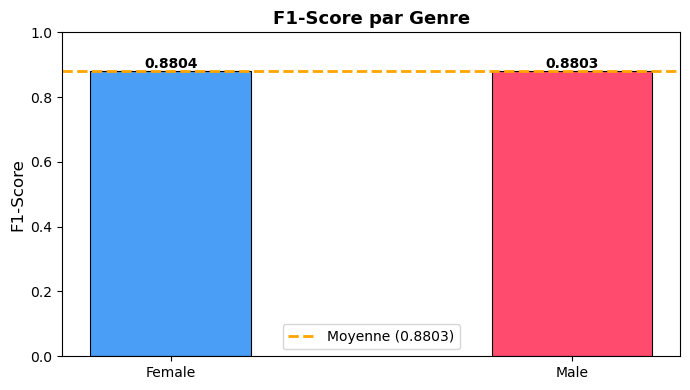

In [4]:
# Biais par Genre
res_genre = analyser_biais(df, 'Gender', 'BIAIS PAR GENRE')

# Graphique
genres = [r['groupe'] for r in res_genre]
f1_vals = [r['f1'] for r in res_genre]

plt.figure(figsize=(7, 4))
barres = plt.bar(genres, f1_vals,
                  color=['#4A9EF5', '#FF4B6E'],
                  edgecolor='black', linewidth=0.8, width=0.4)
plt.axhline(y=np.mean(f1_vals), color='orange', linestyle='--',
            linewidth=2, label=f'Moyenne ({np.mean(f1_vals):.4f})')
plt.ylabel('F1-Score', fontsize=12)
plt.title('F1-Score par Genre', fontsize=13, fontweight='bold')
plt.ylim(0, 1)
plt.legend()
for b, v in zip(barres, f1_vals):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01,
             f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Cellule 5 — Biais par Département

=== BIAIS PAR DÉPARTEMENT ===

Groupe                         Effectif  % Partis       F1      AUC  Équité
---------------------------------------------------------------------------
Human Resources                      63     19.0%   0.8800   0.9526   OK
Research & Development              961     13.8%   0.8722   0.9652   OK
Sales                               446     20.6%   0.8911   0.9956   OK

   Écart max F1 : 0.0189 → Équité satisfaisante



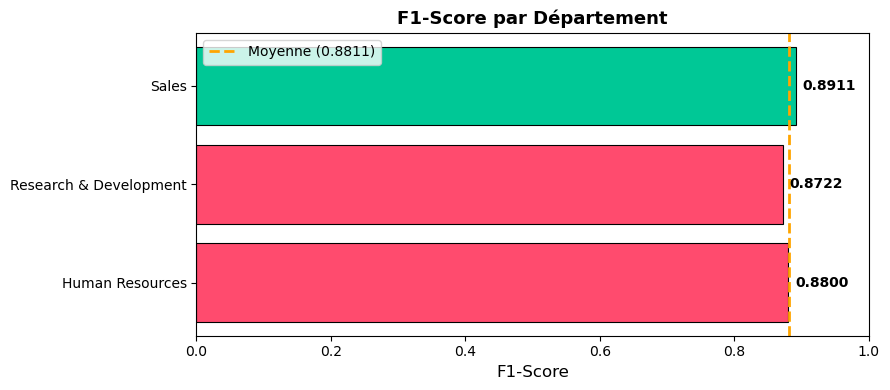

In [5]:
# Biais par Département
res_dept = analyser_biais(df, 'Department', 'BIAIS PAR DÉPARTEMENT')

# Graphique
depts  = [r['groupe'] for r in res_dept]
f1_dep = [r['f1'] for r in res_dept]
coul_d = ['#FF4B6E' if v < np.mean(f1_dep) else '#00C896' for v in f1_dep]

plt.figure(figsize=(9, 4))
barres = plt.barh(depts, f1_dep,
                   color=coul_d, edgecolor='black', linewidth=0.8)
plt.axvline(x=np.mean(f1_dep), color='orange', linestyle='--',
            linewidth=2, label=f'Moyenne ({np.mean(f1_dep):.4f})')
plt.xlabel('F1-Score', fontsize=12)
plt.title('F1-Score par Département', fontsize=13, fontweight='bold')
plt.xlim(0, 1)
plt.legend()
for b, v in zip(barres, f1_dep):
    plt.text(v + 0.01, b.get_y() + b.get_height()/2,
             f'{v:.4f}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
##  Cellule 6 — Biais par Statut Matrimonial

In [6]:
# Biais par Statut Matrimonial
res_marital = analyser_biais(df, 'MaritalStatus', 'BIAIS PAR STATUT MATRIMONIAL')

=== BIAIS PAR STATUT MATRIMONIAL ===

Groupe                         Effectif  % Partis       F1      AUC  Équité
---------------------------------------------------------------------------
Divorced                            327     10.1%   0.8919   0.9978   OK
Married                             673     12.5%   0.8588   0.9686   OK
Single                              470     25.5%   0.8916   0.9679   OK

   Écart max F1 : 0.0331 → Équité satisfaisante



---
##  Cellule 7 — Biais par Niveau d'Éducation

In [7]:
# Biais par Niveau d'Éducation
res_edu = analyser_biais(df, 'Education', "BIAIS PAR NIVEAU D'ÉDUCATION")

=== BIAIS PAR NIVEAU D'ÉDUCATION ===

Groupe                         Effectif  % Partis       F1      AUC  Équité
---------------------------------------------------------------------------
Bachelor                            572     17.3%   0.9179   0.9790   OK
Below College                       170     18.2%   0.8358   0.9675   OK
College                             282     15.6%   0.8791   0.9777   OK
Doctor                               48     10.4%   0.7273   0.8093   OK
Master                              398     14.6%   0.8547   0.9802   OK

    Écart max F1 : 0.1906 → BIAIS POTENTIEL DÉTECTÉ



---
##  Cellule 8 — Synthèse Équité

In [8]:
# Synthèse de tous les biais analysés
print("=" * 60)
print("  SYNTHÈSE ÉQUITÉ DU MODÈLE")
print("=" * 60)
print()

analyses = [
    ('Genre',            res_genre),
    ('Département',      res_dept),
    ('Statut Matrimonial', res_marital),
    ('Niveau Éducation', res_edu),
]

for titre, resultats in analyses:
    f1_vals = [r['f1'] for r in resultats if r['f1'] > 0]
    if len(f1_vals) >= 2:
        ecart = max(f1_vals) - min(f1_vals)
        statut = " Équitable" if ecart <= 0.15 else " Biais potentiel"
        print(f"  {titre:<25} Écart F1 = {ecart:.4f}   {statut}")

print()
print("  Seuil d'alerte : écart > 0.15 entre les groupes")
print()
print("  → Un modèle équitable prédit aussi bien pour tous les groupes.")
print("  → En RH, l'équité algorithmique est un impératif éthique et légal.")
print("=" * 60)

  SYNTHÈSE ÉQUITÉ DU MODÈLE

  Genre                     Écart F1 = 0.0002    Équitable
  Département               Écart F1 = 0.0189    Équitable
  Statut Matrimonial        Écart F1 = 0.0331    Équitable
  Niveau Éducation          Écart F1 = 0.1906    Biais potentiel

  Seuil d'alerte : écart > 0.15 entre les groupes

  → Un modèle équitable prédit aussi bien pour tous les groupes.
  → En RH, l'équité algorithmique est un impératif éthique et légal.


In [ ]:
#conda activate base
#cd C:\Users\HP\projetRHLIG
#streamlit run 7_streamlit.py